# Regresyon Problemlerine Giriş

Bu notebookda **"Regresyon_Temelleri"** notebookumuzda öğrediğimiz temellere ek olarak yeni kavramlar öğrenicek ve örnek veri setleri üzerinde bu öğrendiklerimizi pekiştirme imkanı bulacağız.

Bu dersin sonunda şunları yapabiliyor olmayı hedefliyoruz:

1. Öğrendiğimiz görselleştirme yöntemlerini kullanarak veri setimiz hakkında daha detaylı bilgi edinmek
2. Değişkenler arasında görülen **korelasyon** ve **multicollinearity** kavramlarının ne anlama geldiğini kavramak
3. **Lineer Regresyon** modellerinin nasıl çalıştığını daha iyi kavramak
4. **R2** gibi regresyon analizine ilişkin değerleri nasıl yorulamamız gerektiğini kavramak
5. Model doğruluğunu arttırmak için veri seti üzerinde basit düzeyde **feature engineering** ve **değişken seçme** işlemleri gerçekleştirmek

## Veri Setleri

Bu notebook içerisinde birden fazla farklı veri setiyle çalışacağız.
1. Simple Survey Dataset
2. Car Price Predictor Dataset

## Kütüphane Yükleme

Eğer gerekliyse, bu notebook'da kullanılan kütüphaneleri `pip` komutunu kullanarak yüklememiz gerekiyor.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import patsy
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

# Simple Survey Dataset

In [2]:
df = pd.read_table('https://stats.idre.ucla.edu/wp-content/uploads/2016/02/p054.txt')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Y       30 non-null     int64
 1   X1      30 non-null     int64
 2   X2      30 non-null     int64
 3   X3      30 non-null     int64
 4   X4      30 non-null     int64
 5   X5      30 non-null     int64
 6   X6      30 non-null     int64
dtypes: int64(7)
memory usage: 1.8 KB


In [3]:
df.head()

,Y,X1,X2,X3,X4,X5,X6
0,43,51,30,39,61,92,45
1,63,64,51,54,63,73,47
2,71,70,68,69,76,86,48
3,61,63,45,47,54,84,35
4,81,78,56,66,71,83,47


Eğer sütun isimlerini kontrol edersek, sütun isimlerimizde boşluklar olduğunu görürüz. Ama biz neyse ki bu problemle baş etmeyi öğrendik :)

In [4]:
df.columns

Index(['Y ', 'X1 ', 'X2 ', 'X3 ', 'X4 ', 'X5 ', 'X6 '], dtype='object')

In [5]:
df.columns = df.columns.map(str.strip)
df.columns

Index(['Y', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6'], dtype='object')

## Görsel Çıktıları Yorumlama

Veri setimiz, toplamda 7 sütundan (6 feature, 1 target) ve 30 satırdan oluştuğunu görüyoruz. Farklı değişkenler arasındaki ilişkileri incelemek için hesaplanan korelasyon değerlerine bakalım.

In [6]:
df.corr() # Değişkenler arasındaki korelasyon değerlerini inceleme (Önemli!)

,Y,X1,X2,X3,X4,X5,X6
Y,1.000000,0.825418,0.426117,0.623678,0.590139,0.156439,0.155086
X1,0.825418,1.000000,0.558288,0.596736,0.669197,0.187714,0.224580
X2,0.426117,0.558288,1.000000,0.493331,0.445478,0.147233,0.343293
X3,0.623678,0.596736,0.493331,1.000000,0.640314,0.115965,0.531620
X4,0.590139,0.669197,0.445478,0.640314,1.000000,0.376883,0.574186
X5,0.156439,0.187714,0.147233,0.115965,0.376883,1.000000,0.283343
X6,0.155086,0.224580,0.343293,0.531620,0.574186,0.283343,1.000000


Hesaplanan korelasyon değerleri arasındaki büyüklük küçüklük ilişkisini daha iyi şekilde inceleyebilmek için `heatmap` görselinden yararlanalım.

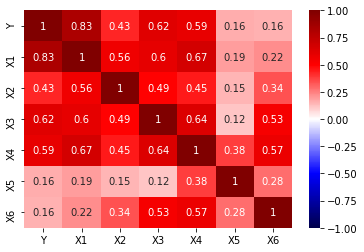

In [7]:
sns.heatmap(df.corr(), cmap="seismic", annot=True, vmin=-1, vmax=1);

## Multicollinearity

Üstteki korelasyon haritasını incelediğimizde bazı değişkenlerin yüksek derecede ilişkili olduğunu fark ediyoruz. Bu aşamada dikkate almamız gereken 2 tane durum var;
1. Target sütunumuzu (Y) baz aldığımızda özellikle **X1**'in yapacağımız tahmini diğer featurelara kıyasla daha çok etkilediğini görüyoruz. Bu durum kesinlikle istediğimiz bir şey çünkü ne kadar büyük katsayılı değerlerimizin olması, bunların büyük olasılıkla modelimizin bir parçası olarak dahil etmek istediğimiz değişkenler olduğu anlamına gelir. 
2. Ancak tabloya baktığımızda korelasyon değerleri sadece target sütunu bazında hesaplanmamış, featurelar arasında da korelasyon değerleri var ve aralarında **0.67** ve **0.64** gibi güçlü ilişkileri temsil eden korelasyon değerleri var.

> **SORU:** Featurelar arasında görülen bu ilişkileri nasıl yorumlamamız gerek?

Makine öğrenmesi modellerinde genellikle birbiriyle yüksek ilişkili gösteren durumlar sevilir ama genellikle! Eğer bulunan bu yüksek ilişkiler featurelar arasında ise bu büyük bir sorun **multicollinearity** olarak adlandırılır. Şimdi bu durumun bizim için neden bir sorun teşkil ettiğini bir örnekle daha iyi kavrayalım.

> **SORU:** Elinizde aşağıdaki tablodaki gibi bir veri seti olsun. Bu veri setini kullanmamızdaki ana amaç aslında listelenen evlere ait fiyat tahmini yapabilmek. Peki sizce bu veri setinde bir multicollinearity sorunu olabilir mi?

![multicollinearity_problem](data/multicollinearity.png)

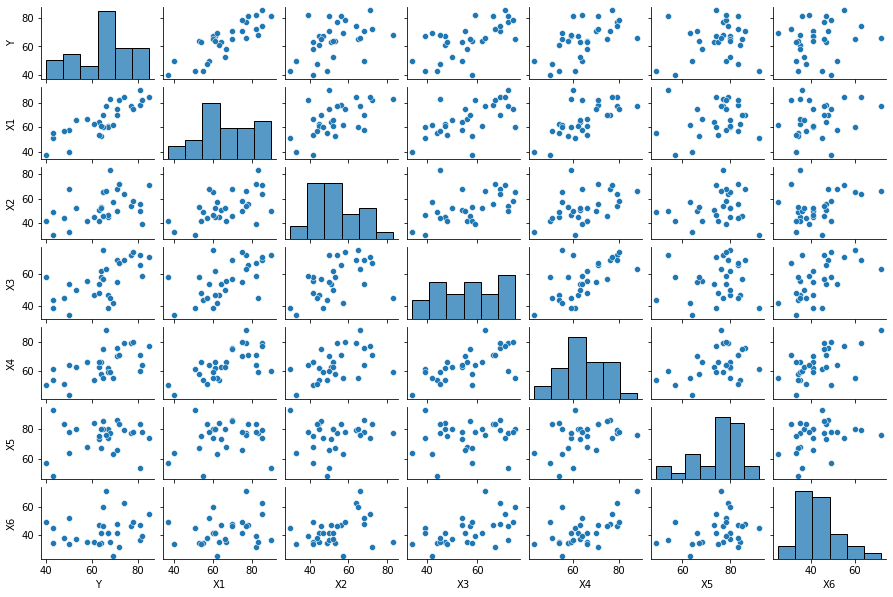

In [8]:
sns.pairplot(df, height=1.2, aspect=1.5);

## Statsmodels Kullanarak Modelleme

Statsmodels yaklaşımıyla modeller oluşturmanın 2 yolu vardır:

- `statsmodels.api` yöntemini kullanmak (ilk notebookda bu yöntemi kullanmıştık)
- `statsmodels.formula.api` yöntemini kullanmak

Bu 2 yöntem de temelde aynı işlevi görseler de kullanım açısından birbirlerinden küçük bir farkları var. Şimdi bu farkın ne olduğunu görelim.

### `statsmodels.api`

Bu yöntemi kullanmak için, öncesinde featurelarımıza ait değerleri barındıran bir matris değişkenine ve target sütunumuza ait değerleri barındıran bir matris değişkenine daha ihtiyacımız var. Bu işlemi daha önce öğrendiğimiz yöntemlerle yapabileceğimiz gibi, `patsy.dmatrices` yardımıyla da yapabiliriz.

In [9]:
# Değişkenlerin tanımlaması
y, X = patsy.dmatrices('Y ~ X1 + X2 + X3 + X4 + X5 + X6', data=df, return_type="dataframe")

# Modeli Oluşturma
model = sm.OLS(y, X)

# Modeli Eğitme
fit = model.fit()

# Oluşturduğumuz modele ilişkin istatistiksel değerleri görüntüleme
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.733
Model:                            OLS   Adj. R-squared:                  0.663
Method:                 Least Squares   F-statistic:                     10.50
Date:                Wed, 29 Jun 2022   Prob (F-statistic):           1.24e-05
Time:                        01:11:03   Log-Likelihood:                -97.250
No. Observations:                  30   AIC:                             208.5
Df Residuals:                      23   BIC:                             218.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.7871     11.589      0.931      0.362     -13.187      34.761
X1             0.6132      0.161      3.809      0.001       0.280       0.946
X2            -0.0731      0.136     -0.538      0.596      -0.354       0.208
X3             0.3203      0.169      1.901      0.070      -0.028       0.669
X4             0.0817      0.221      0.369      0.715      -0.376       0.540
X5             0.0384      0.147      0.261      0.796      -0.266       0.342
X6            -0.2171      0.178     -1.218      0.236      -0.586       0.152
==============================================================================
Omnibus:                        2.386   Durbin-Watson:                   1.795
Prob(Omnibus):                  0.303   Jarque-Bera (JB):                1.255
Skew:                          -0.081   Prob(JB):                        0.534
Kurtosis:                       2.011   Cond. No.                     1.34e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.34e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### `statsmodels.formula.api`

Bu yöntemde ise bizim `X` ve `Y` değişkenlerimizi tanımlamamıza gerek yok, bunu zaten kendi içerisinde bizim için yapıyor :)

In [10]:
# Modeli Oluşturma
lm1 = smf.ols('Y ~ X1 + X2 + X3 + X4 + X5 + X6', data=df)

# Modeli Eğitme
fit1 = lm1.fit()

# Oluşturduğumuz modele ilişkin istatistiksel değerleri görüntüleme
fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.733
Model:                            OLS   Adj. R-squared:                  0.663
Method:                 Least Squares   F-statistic:                     10.50
Date:                Wed, 29 Jun 2022   Prob (F-statistic):           1.24e-05
Time:                        01:11:03   Log-Likelihood:                -97.250
No. Observations:                  30   AIC:                             208.5
Df Residuals:                      23   BIC:                             218.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.7871     11.589      0.931      0.362     -13.187      34.761
X1             0.6132      0.161      3.809      0.001       0.280       0.946
X2            -0.0731      0.136     -0.538      0.596      -0.354       0.208
X3             0.3203      0.169      1.901      0.070      -0.028       0.669
X4             0.0817      0.221      0.369      0.715      -0.376       0.540
X5             0.0384      0.147      0.261      0.796      -0.266       0.342
X6            -0.2171      0.178     -1.218      0.236      -0.586       0.152
==============================================================================
Omnibus:                        2.386   Durbin-Watson:                   1.795
Prob(Omnibus):                  0.303   Jarque-Bera (JB):                1.255
Skew:                          -0.081   Prob(JB):                        0.534
Kurtosis:                       2.011   Cond. No.                     1.34e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.34e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Regresyon İstatistikleri

Bir önceki notebookumuzda bu tabloda karşımıza çıkan değerleri yorumlama kısmını biraz daha detaylandıracağımızı söylemiştik, şimdi sıra geldi karşımıza çıkan bu koca tablodaki değerlerden ne anlamalıyız kısmına :)

- **R<sup>2</sup> (R-Squared)** değeri regresyon modelimiz tarafından açıklanabilen, target değişkenimiz olan Y'ye ilişkin gerçekleştirilen tahminlerin doğruluk yüzdesini temsil eder.  
- İsmen birbirlerine benzeseler de **Adjusted R<sup>2</sup> (Adj. R-Squared)** değerinin yorumlanması **R<sup>2</sup>**'den biraz daha farklıdır. Adjusted R<sup>2</sup> değeri modelimizde bulunan küçük katsayı değerlerine sahip featureları ve gereksiz featureları bizim için daha iyi bir model oluşturabilmemiz için cezalandırır ve ona göre bir değer hesabı gerçekleştirir. Bu işlem aynı zamanda **overfitting** (daha detaylı konuşacağız) adını verdiğimiz sorunun da önüne geçmemizde bize katkı sağlar.
- **Standard Error (std err)**, model tarafından hesaplanan katsayının standart sapmasının bir tahminidir ve bulunan katsayının  kesinliği hakkında bilgi veren bir ölçüdür. Eğer incelediğimiz feature, yüksek bir katsayı değerine sahip ve bunun yanında düşük bir standart hatasıyla bizim karşımıza çıkmışsa, bu incelediğimiz katsayının yüksek bir öneme sahip olduğu anlamına gelen yüksek bir **t** istatistiği üretir.
- **P>|t|** değeri özetteki en önemli istatistiklerden biridir. Katsayılarımızın modelimiz aracılığıyla şans eseri ölçülme olasılığının bir ölçüsünü ifade eder. Örneğin, **X5** sütünu için 0.796 olan bir p değeri, **X5** bağımsız değişkeninin, bağımlı değişken olan **Y** üzerinde hiçbir etkisinin olmaması olasılığının %79.6 olduğunu ve buna dair sonuçların bize tesadüfen üretildiğini söylüyor.
- **Skewness (Skew)** çalıştığımız veriye ilişkin çarpıklık değerini bize söyler. **Pozitif (+)** çarpıklık değerleri dağılımın solda toplandığını, **negatif (-)** çarpıklık değerleri dağılımın sağda toplandığını, 0'a yakın çarpıklık değerleri ise verimizin simetrik dağılım gösterdiği şekilde bilgi verir. Yüksek çarpıklık değerleri bize veri setimiz içerisinde **aykırı değerler (outliers)** olabileceğine dair ipucu sağlarlar.
- **Kurtosis** çalıştığımız veriye ilişkin basıklık değerini bize söyler. **Pozitif (+)** basıklık değerleri sivri dağılımları, **negatif (-)** basıklık değerleri grafiğin tabanına yayılan dağılımları, 0'a yakın basıklık değerleri ise verimizin simetrik dağılım gösterdiği şekilde bilgi verir. Aynı çarpıklıkta da olduğu gibi çok yüksek basıklık değerleri bize veri setimiz içerisinde **aykırı değerler (outliers)** olabileceğine dair ipucu sağlarlar.
- **Condition Number (Cond. No.)** multicollinearity gibi sayısal problemler hakkında bilgi verir. Düşük condition number değerleri bizim istediğimiz durumları temsil ederken, yüksek condition number değerleri veri setimiz içerisinde bazı sayısal problemler olduğunu söyler.

Artık konuştuğumuz bu detaylara göre öğrendiklerimizi verimiz üzerinde uygulayalım.

**P>|t|** değerinin 1'e yakın değerler olması istediğimiz bir durum değildi. Bu yüzden regresyon modelimizde en yüksek 3 **p-value** değerine sahip olan değişkenlerimizi modelimizden çıkartalım ve modelimizde nasıl bir etkisi olduğunu konuşalım.

In [11]:
# X2, X4, X5 sütunları kaldırıldı
lm2 = smf.ols('Y ~ X1 + X3 + X6', data=df)

fit2 = lm2.fit()

fit2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.726
Model:                            OLS   Adj. R-squared:                  0.694
Method:                 Least Squares   F-statistic:                     22.92
Date:                Wed, 29 Jun 2022   Prob (F-statistic):           1.81e-07
Time:                        01:11:03   Log-Likelihood:                -97.638
No. Observations:                  30   AIC:                             203.3
Df Residuals:                      26   BIC:                             208.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.5777      7.544      1.800      0.084      -1.929      29.084
X1             0.6227      0.118      5.271      0.000       0.380       0.866
X3             0.3124      0.154      2.026      0.053      -0.005       0.629
X6            -0.1870      0.145     -1.291      0.208      -0.485       0.111
==============================================================================
Omnibus:                        2.856   Durbin-Watson:                   1.938
Prob(Omnibus):                  0.240   Jarque-Bera (JB):                1.394
Skew:                          -0.121   Prob(JB):                        0.498
Kurtosis:                       1.972   Cond. No.                         605.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

> **SORU:** Yaptığımız bu değişiklikten sonra **R<sup>2</sup>** değerimizde bir küçük bir azalma olmasına rağmen **Adjusted R<sup>2</sup>** değerimizde bir artış yakaladığımızı görüyoruz. Bu durum bizim için ne ifade ediyor?

Bu yaptığımız işlem sonucunda modelimiz biraz daha iyileşmiş gibi duruyor. O zaman modelimizi biraz daha geliştirip geliştirmeyeceğini görmek için **X6**'yı da kaldırmayı deneyelim.

In [12]:
# X6 sütunu kaldırıldı
lm3 = smf.ols('Y ~ X1 + X3', data=df)

fit3 = lm3.fit()

fit3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     32.74
Date:                Wed, 29 Jun 2022   Prob (F-statistic):           6.06e-08
Time:                        01:11:03   Log-Likelihood:                -98.569
No. Observations:                  30   AIC:                             203.1
Df Residuals:                      27   BIC:                             207.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.8709      7.061      1.398      0.174      -4.618      24.359
X1             0.6435      0.118      5.432      0.000       0.400       0.887
X3             0.2112      0.134      1.571      0.128      -0.065       0.487
==============================================================================
Omnibus:                        6.448   Durbin-Watson:                   1.958
Prob(Omnibus):                  0.040   Jarque-Bera (JB):                1.959
Skew:                          -0.041   Prob(JB):                        0.375
Kurtosis:                       1.751   Cond. No.                         503.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Bu sefer olmadı! Yaptığımız bu işlem her iki **R<sup>2</sup>** katsayımızda da düşüşe neden oldu. Biz en iyisi oluşturduğumuz 2. modelle yola devam edelim.

> **NOT:** `Statsmodels`, lineer modeller için yeterli işlevselliğe sahiptir ve istatistiksel özetler için mükemmel bir araçtır. Ancak, `scikit-learn`, veri hazırlamanın yanı sıra lineer olmayan algoritmalar için daha fazla modelleme seçeneğine sahiptir ve her geçen gün büyümektedir, bu nedenle genel olarak bundan sonra bununla çalışacağız.

## Sklearn Kullanarak Modelleme

Sklearn'ün bazı ek özelliklerine geçmeden önce, sklearn'ün `LinearRegression()` özelliğini kullanarak Simple Survey Dataset örneğimizi tekrarlamaya çalışalım.

Bunun için öncelikle denediğimiz farklı modellerden elde ettiğimiz sonuçların bazılarını sklearn ile tekrardan oluşturalım ve arada bir fark var mı ona bakalım. İşte ilk model:

In [13]:
# Modeli Oluşturma
lr1 = LinearRegression()

# Choose the predictor variables, here all but the first which is the response variable
# Featurelara Karar Verme
X = df.iloc[:, 1:]

# Targetı Oluşturma
y = df.iloc[:, 0]

# Modeli Eğitme
lr1.fit(X, y)

# R2 Değeri
r_squared1 = lr1.score(X,y)
print(("R2: ", r_squared1))

# Adjusted R2 Değeri
adjusted_r_squared1 = 1 - (1-r_squared1)*(len(y)-1)/(len(y)-X.shape[1]-1)
print("Adjusted R2: ", adjusted_r_squared1)

('R2: ', 0.7326019925311491)
Adjusted R2:  0.6628459905827533


Elde ettiğimiz sonucun, yukarıda oluşturduğumuz ilk `statsmodels` modeli için bildirilenle aynı **R<sup>2</sup>** ve **Adjusted R<sup>2</sup>** değerleri olduğunu fark edeceksiniz. 

O zaman, daha önceki en iyi modeli **(X1, X3 ve X6)** hızlıca çalıştıralım ve nasıl performans gösterdiğini görelim.

In [14]:
lr2 = LinearRegression()

X = df[['X1', 'X3', 'X6']]

y = df['Y']

lr2.fit(X, y)

r_squared2 = lr2.score(X, y)
print("R2: ", r_squared2)

adjusted_r_squared2 = 1 - (1-r_squared2)*(len(y)-1)/(len(y)-X.shape[1]-1)
print("Adjusted R2: ", adjusted_r_squared2)

R2:  0.7255949995745075
Adjusted R2:  0.6939328841407968


**R<sup>2</sup>** ve **Adjusted R<sup>2</sup>** değerlerinin tekrar aynı olduğuna dikkat edin. Bu durum, yaklaşım tarzları kısmen farklı olsa da her 2 yöntemi de kullanarak benzer sonuçlar alacağımızı göstermiş oldu. Artık, `statsmodels` ve `sklearn` ile basit lineer modelleri nasıl yapabileceğimizi gördük.

Hadi bir de `sklearn` modelimiz tarafından oluşturulan katsayılara ve sabit değere bakalım.

In [15]:
# lr2 modelinden elde edilen katsayı değerleri
print(lr2.coef_)

# lr2 modelinden elde edilen sabit değer
print(lr2.intercept_)

[ 0.62272975  0.31238698 -0.18695081]
13.577741068163903


## Veri Setimizi & Modelimizi Sonrasında Tekrardan Kullanmak İçin Kaydetme

Çoğu zaman oluşturduğumuz veri setlerini ve modelleri sonradan tekrar tekrar kullanmak isteriz. O halde, onları saklayalım...

Neyse ki `pickle` kullanarak `pandas`, `statsmodels` ve `sklearn`den elde ettiğimiz çıktıları saklamak oldukça kolay :)

**Pandas:**

Oluşturduğumuz `DataFrame`leri saklamak için `to_pickle()` fonksiyonunu kullanabiliriz.

In [16]:
df.to_pickle('data/survey_data.pkl')

**Statsmodels:**

`statsmodels` modelleri için `save()` fonksiyonunu

In [17]:
fit2.save('data/survey_sm_model.pkl')

**Sklearn:**

`sklearn` modelleri için ise `sklearn` kütüphanesinin bir özelliği olan `joblib`den yardım almamız gerekiyor.

In [18]:
from joblib import dump, load

dump(lr2, 'data/survey_sk_model.pkl')
lr2 = load('data/survey_sk_model.pkl')

# Gerçek Hayat Örneği: Car Price Predictor Dataset

Şimdiki yapacağımız örnekte araba fiyatı tahmin etmek için [Car Price Predictor Dataset](https://archive.ics.uci.edu/ml/datasets/Automobile)i kullanacağız.

> **NOT:** Veriyle boğuşmaya başlamadan önce [MetaData](https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.names) içerisinden veri hakkında genel bilgi edinmeyi ihmal etmeyin!

## Veriyi Keşfetme

In [19]:
df = pd.read_csv('http://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data', header=None)

columns= ['symboling','normalized-losses','make','fuel-type','aspiration','num-of-doors','body-style','drive-wheels',
          'engine-location','wheel-base','length','width','height','curb-weight','engine-type','num-of-cylinders','engine-size',
          'fuel-system','bore','stroke','compression-ratio','horsepower','peak-rpm','city-mpg', 'highway-mpg','price']
df.columns = columns

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

İlk bakışta veri setimiz içerisinde herhangi bir boş değer gözükmüyor. Ancak oldukça fazla sayıda object(str) verimiz var, bu durum bizim hoşumuza giden bir şey değil. Ama object sütunlarına ne yapmamız gerektiğini 2. aşamada konuşacağız.

In [21]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


- Bu kısımda, info fonksiyonunu kullanarak göremediğimiz başka sorunlar görüyoruz. Veri setimiz içerisinde **?** ifadeleri var. Yani bu **?**'lerinin, NaN (boş) değerleri temsil ediyor olması lazım. Hadi hemen bu sorunun önüne geçelim.

In [22]:
for column in columns:
    df[column] = df[column].replace('?',np.nan)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

- Tabiki, bu aşamayı bitirmeden önce veri tiplerimizi düzeltmeyi de unutmuyoruz :)

In [23]:
numeric_columns = ['normalized-losses','bore','stroke','horsepower','peak-rpm','price']

for column in numeric_columns:
    df[column] = df[column].astype(float)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

Yukarıda elde ettiğimiz çıktıdan, ilk etapta veri setimiz içerisindeki bazı değerlerin bilinmediğini görüyoruz. Şimdilik işleri basit tutmak için, devam edelim ve bilinmeyen değerleri veri setimiz içerisinden kaldıralım.

>**NOT:** Aslında boş değerler barındıran satırları silmek bizim en son uygulamamız gereken yöntemdir. İlerleyen derslerde bu konuya daha detaylı bir şekilde eğiliyo olacağız :)

In [24]:
df.dropna(inplace=True)
len(df)

159

>**SORU:** Ama ben veri setinin içeriğini incelerken gözüme çarpan bir durum daha vardı. Bunu yakalayabildik mi?

In [25]:
df['num-of-doors'] = df['num-of-doors'].apply(lambda x: str(x).replace('four', '4'))
df['num-of-doors'] = df['num-of-doors'].apply(lambda x: str(x).replace('two', '2'))
df['num-of-doors'] = df['num-of-doors'].astype(int)

In [26]:
df['num-of-cylinders'] = df['num-of-cylinders'].apply(lambda x: str(x).replace('two', '2'))
df['num-of-cylinders'] = df['num-of-cylinders'].apply(lambda x: str(x).replace('three', '3'))
df['num-of-cylinders'] = df['num-of-cylinders'].apply(lambda x: str(x).replace('four', '4'))
df['num-of-cylinders'] = df['num-of-cylinders'].apply(lambda x: str(x).replace('five', '5'))
df['num-of-cylinders'] = df['num-of-cylinders'].apply(lambda x: str(x).replace('six', '6'))
df['num-of-cylinders'] = df['num-of-cylinders'].apply(lambda x: str(x).replace('eight', '8'))
df['num-of-cylinders'] = df['num-of-cylinders'].apply(lambda x: str(x).replace('twelve', '12'))
df['num-of-cylinders'] = df['num-of-cylinders'].astype(int)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 159 entries, 3 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          159 non-null    int64  
 1   normalized-losses  159 non-null    float64
 2   make               159 non-null    object 
 3   fuel-type          159 non-null    object 
 4   aspiration         159 non-null    object 
 5   num-of-doors       159 non-null    int32  
 6   body-style         159 non-null    object 
 7   drive-wheels       159 non-null    object 
 8   engine-location    159 non-null    object 
 9   wheel-base         159 non-null    float64
 10  length             159 non-null    float64
 11  width              159 non-null    float64
 12  height             159 non-null    float64
 13  curb-weight        159 non-null    int64  
 14  engine-type        159 non-null    object 
 15  num-of-cylinders   159 non-null    int32  
 16  engine-size        159 non

- Henüz `object` veri tipindeki sütunları kullanarak modeller oluşturmayı öğrenmedik. O yüzden ilk aşamada sadece sayısal sütunlarla ilerleyelim.

In [28]:
subset = ['normalized-losses','num-of-doors','wheel-base','length','width','height',
          'curb-weight','num-of-cylinders','engine-size','bore','stroke','compression-ratio',
          'horsepower','peak-rpm','city-mpg','highway-mpg','price']

cars = df.loc[:,subset]

cars.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 159 entries, 3 to 204
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   normalized-losses  159 non-null    float64
 1   num-of-doors       159 non-null    int32  
 2   wheel-base         159 non-null    float64
 3   length             159 non-null    float64
 4   width              159 non-null    float64
 5   height             159 non-null    float64
 6   curb-weight        159 non-null    int64  
 7   num-of-cylinders   159 non-null    int32  
 8   engine-size        159 non-null    int64  
 9   bore               159 non-null    float64
 10  stroke             159 non-null    float64
 11  compression-ratio  159 non-null    float64
 12  horsepower         159 non-null    float64
 13  peak-rpm           159 non-null    float64
 14  city-mpg           159 non-null    int64  
 15  highway-mpg        159 non-null    int64  
 16  price              159 non

In [29]:
cars.head()

,normalized-losses,num-of-doors,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
3,164.0,4,99.8,176.6,66.2,54.3,2337,4,109,3.19,3.4,10.0,102.0,5500.0,24,30,13950.0
4,164.0,4,99.4,176.6,66.4,54.3,2824,5,136,3.19,3.4,8.0,115.0,5500.0,18,22,17450.0
6,158.0,4,105.8,192.7,71.4,55.7,2844,5,136,3.19,3.4,8.5,110.0,5500.0,19,25,17710.0
8,158.0,4,105.8,192.7,71.4,55.9,3086,5,131,3.13,3.4,8.3,140.0,5500.0,17,20,23875.0
10,192.0,2,101.2,176.8,64.8,54.3,2395,4,108,3.50,2.8,8.8,101.0,5800.0,23,29,16430.0


Modellemeye başlamadan önce, özellikle **price** ile ilgili olarak farklı değişkenler arasındaki korelasyonlar hakkında bir fikir edinmek için korelasyon değerlerine bakalım.

In [30]:
cars.corr()

,normalized-losses,num-of-doors,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
normalized-losses,1.000000,-0.393539,-0.060086,0.035541,0.109726,-0.413702,0.125858,0.268157,0.207820,-0.031558,0.063330,-0.127259,0.290511,0.237697,-0.235523,-0.188564,0.202761
num-of-doors,-0.393539,1.000000,0.427991,0.412630,0.246905,0.468731,0.259201,-0.013527,0.085100,0.214539,-0.028945,0.115414,0.029959,-0.168896,-0.165831,-0.160870,0.162152
wheel-base,-0.060086,0.427991,1.000000,0.871534,0.814991,0.555767,0.810181,0.312733,0.649206,0.578159,0.167449,0.291431,0.516948,-0.289234,-0.580657,-0.611750,0.734419
length,0.035541,0.412630,0.871534,1.000000,0.838338,0.499251,0.871291,0.389477,0.725953,0.646318,0.121073,0.184814,0.672063,-0.234074,-0.724544,-0.724599,0.760952
width,0.109726,0.246905,0.814991,0.838338,1.000000,0.292706,0.870595,0.507360,0.779253,0.572554,0.196619,0.258752,0.681872,-0.232216,-0.666684,-0.693339,0.843371
height,-0.413702,0.468731,0.555767,0.499251,0.292706,1.000000,0.367052,-0.058612,0.111083,0.254836,-0.091313,0.233308,0.034317,-0.245864,-0.199737,-0.226136,0.244836
curb-weight,0.125858,0.259201,0.810181,0.871291,0.870595,0.367052,1.000000,0.595873,0.888626,0.645792,0.173844,0.224724,0.790095,-0.259988,-0.762155,-0.789338,0.893639
num-of-cylinders,0.268157,-0.013527,0.312733,0.389477,0.507360,-0.058612,0.595873,1.000000,0.770809,0.134820,0.132264,0.061637,0.618514,-0.118165,-0.484712,-0.519366,0.641578
engine-size,0.207820,0.085100,0.649206,0.725953,0.779253,0.111083,0.888626,0.770809,1.000000,0.595737,0.299683,0.141097,0.812073,-0.284686,-0.699139,-0.714095,0.841496
bore,-0.031558,0.214539,0.578159,0.646318,0.572554,0.254836,0.645792,0.134820,0.595737,1.000000,-0.102581,0.015119,0.560239,-0.312269,-0.590440,-0.590850,0.533890


- Korelasyon haritaları üretirken `heatmap()` kullanmak değerlerin anlaşılmasını ciddi derecede kolaylaştıracaktır.

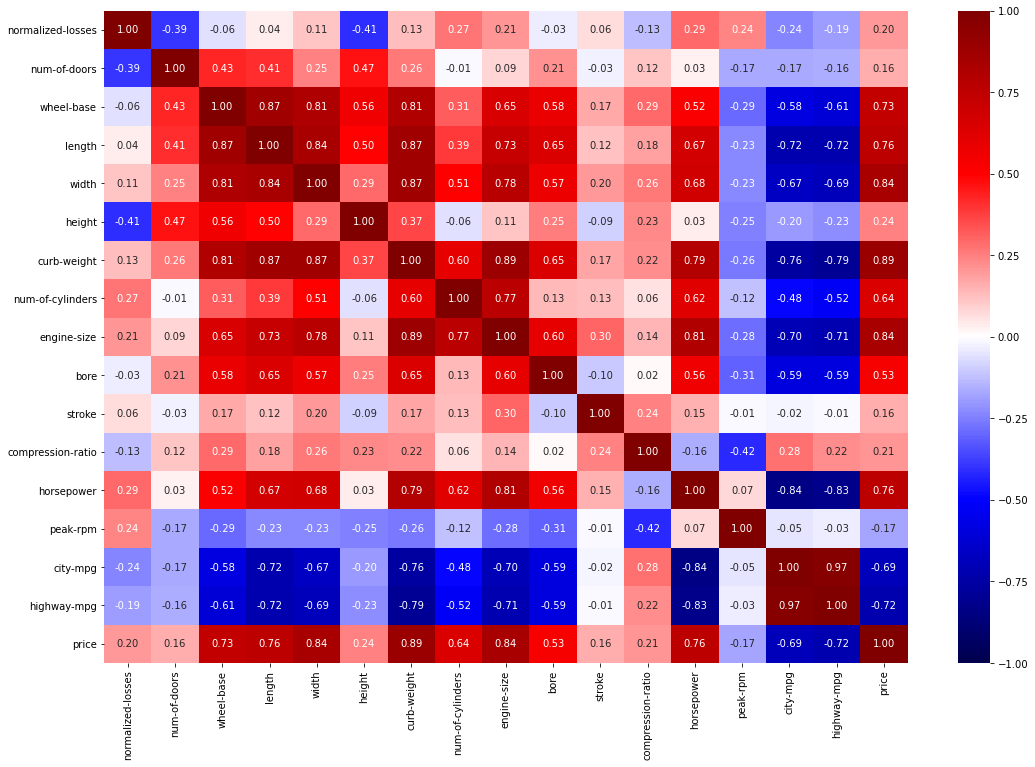

In [31]:
plt.figure(figsize=[18,12])
sns.heatmap(cars.corr(), cmap="seismic", annot=True, vmin=-1, vmax=1, fmt='.2f');

- Korelasyon değerlerimizi şu anda yalnızca target sütunumuz olan **price** sütunu bazında inceleyelim. Ama unutmamalıyız ki featurelarımız arasında bulunan korelasyon değerlerini de incelemek bizler için oldukça önemli!

In [32]:
cars.corr()['price'].sort_values(ascending=False)

price                1.000000
curb-weight          0.893639
width                0.843371
engine-size          0.841496
length               0.760952
horsepower           0.759874
wheel-base           0.734419
num-of-cylinders     0.641578
bore                 0.533890
height               0.244836
compression-ratio    0.209361
normalized-losses    0.202761
num-of-doors         0.162152
stroke               0.160664
peak-rpm            -0.171916
city-mpg            -0.692273
highway-mpg         -0.720090
Name: price, dtype: float64

Artık modeliniz için hangi featureların en değerli olabileceğini daha iyi anlamalıyız.

> **SORU:** Korelasyonlar, modelimizde neler olduğuna dair bize **tüm resmi** sağlıyor mu?  
**CEVAP:** Hayır! Bize bir fikir verebilir, ancak korelasyon değerleri **yalnızca yanıt değişkeni** ile ilişkiyi sağlar (diğer tüm faktörler sabit tutulur).

## Statsmodels Kullanarak Modelleme

Sonunda modelleme aşamasına geldik.  İlk modelimizde, **price** sütunuyla olan korelasyon değeri en az **0.25** olarak hesaplanan featureları modelimize girdi olarak verelim.

In [33]:
cars.rename(columns = {'curb-weight':'curb_weight', 'engine-size':'engine_size', 'wheel-base':'wheel_base', 
                       'num-of-cylinders':'num_of_cylinders', 'city-mpg':'city_mpg', 'highway-mpg':'highway_mpg'},
            inplace=True)

In [34]:
# Modeli Eğitme ve Model Sonucunu Görüntüleme
lsm = smf.ols('price ~ curb_weight + width + engine_size + length + horsepower + wheel_base + num_of_cylinders + bore + city_mpg + highway_mpg', data = cars)
fit1 = lsm.fit()
fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     80.52
Date:                Wed, 29 Jun 2022   Prob (F-statistic):           1.01e-54
Time:                        01:11:05   Log-Likelihood:                -1457.0
No. Observations:                 159   AIC:                             2936.
Df Residuals:                     148   BIC:                             2970.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept        -6.835e+04   1.33e+04     -5.146      0.000   -9.46e+04   -4.21e+04
curb_weight          6.4419      1.412      4.563      0.000       3.652       9.232
width              817.1945    221.363      3.692      0.000     379.754    1254.635
engine_size         -4.5511     22.096     -0.206      0.837     -48.215      39.113
length             -87.7771     45.790     -1.917      0.057    -178.263       2.709
horsepower          30.6336     14.551      2.105      0.037       1.878      59.389
wheel_base         173.9359     88.604      1.963      0.052      -1.157     349.029
num_of_cylinders  1322.1048    625.931      2.112      0.036      85.188    2559.021
bore              -257.0786   1219.912     -0.211      0.833   -2667.774    2153.617
city_mpg           -13.0883    148.488     -0.088      0.930    -306.519     280.342
highway_mpg         48.8751    141.204      0.346      0.730    -230.162     327.912
==============================================================================
Omnibus:                       13.571   Durbin-Watson:                   0.804
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               17.590
Skew:                           0.536   Prob(JB):                     0.000152
Kurtosis:                       4.227   Cond. No.                     1.77e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.77e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

- İlk oluşturduğumuz modelimizde **R<sup>2</sup>** ve **Adjusted R<sup>2</sup>** değerlerimiz **0.845** ve **0.834** olarak karşımıza çıktı. İlk adım için hiç de fena bir skor değil.

> **SORU:** Dersin ilk kısmında konuştuğumuz konuları hatırlıyor muyuz? Bu modeli iyileştirmek için ne yapılabilir?

In [35]:
lsm = smf.ols('price ~ curb_weight + width + length + horsepower + wheel_base + num_of_cylinders', data = cars)
fit2 = lsm.fit()
fit2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.844
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     137.2
Date:                Wed, 29 Jun 2022   Prob (F-statistic):           9.54e-59
Time:                        01:11:06   Log-Likelihood:                -1457.3
No. Observations:                 159   AIC:                             2929.
Df Residuals:                     152   BIC:                             2950.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept        -6.621e+04   1.13e+04     -5.840      0.000   -8.86e+04   -4.38e+04
curb_weight          6.0987      1.191      5.119      0.000       3.745       8.452
width              818.2140    217.762      3.757      0.000     387.983    1248.445
length             -90.4939     42.819     -2.113      0.036    -175.092      -5.896
horsepower          25.0045     11.177      2.237      0.027       2.923      47.086
wheel_base         169.7039     86.308      1.966      0.051      -0.814     340.222
num_of_cylinders  1295.4418    394.714      3.282      0.001     515.608    2075.276
==============================================================================
Omnibus:                       12.675   Durbin-Watson:                   0.806
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               15.621
Skew:                           0.527   Prob(JB):                     0.000405
Kurtosis:                       4.116   Cond. No.                     1.52e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.52e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

- İkinci modelimizde, **P>|t|** değeri büyük olan featureları modelimizden kaldırmak mantıklı bir işlemdi. Ve bu işlem sonucunda **R<sup>2</sup>** ve **Adjusted R<sup>2</sup>** değerlerimiz **0.844** ve **0.838** olarak güncellenmiş oldu.

## Dağılımları Anlamak

İstatistik kısmında konuştuğumuz gibi elimizdeki değişkenin nasıl bir dağılım gösterdiği oldukça önemli bir parametredir. Eğer veri bilimcilere sorarsanız ellerindeki tüm değişkenlerin normal (simetrik) olarak dağılmasını isterler. Ama gerçek hayatta bu tabiki çok mümkün bir senaryo değil :)

Şimdi biz de target sütunumuza dair dağılımı görebilmek için bir histogram grafiği çizdirelim.

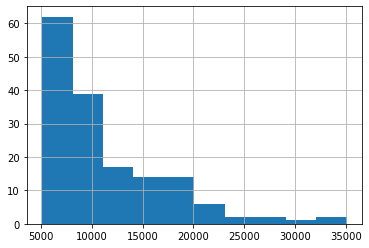

In [36]:
cars.price.hist();

> **SORU:** Karşımıza çıkan bir grafiği nasıl yorumlamamız gerekiyor?

Bu tarz durumlarla baş etmek için sıklıkla kullandığımız yöntemlerden birisi verilere çeşitli dönüşümler uygulamaktır. Bu dönüşümler sayesinde verimizin dağılımını normal dağılıma yaklaştırarak genellikle oluşturduğumuz modelin daha iyi çalışmasını sağlarız. Peki nasıl mı? Hemen bir örnek üzerinde görelim.

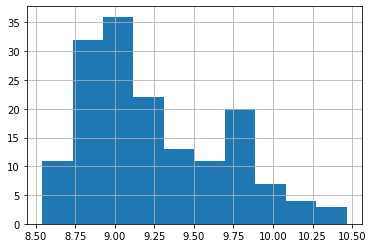

In [37]:
cars['log_price'] = np.log(cars.price)

# Artık dağılım daha iyi gözüküyor :)
cars.log_price.hist();

- Peki yaptığımız bu işlemin modelimizin başarısına gerçekten bir etkisi oldu mu?

In [38]:
# refit and summarize
lsm = smf.ols('log_price ~ curb_weight + width + length + horsepower + wheel_base + num_of_cylinders', data = cars)
fit3 = lsm.fit()
fit3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_price   R-squared:                       0.878
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     182.5
Date:                Wed, 29 Jun 2022   Prob (F-statistic):           7.82e-67
Time:                        01:11:06   Log-Likelihood:                 71.905
No. Observations:                 159   AIC:                            -129.8
Df Residuals:                     152   BIC:                            -108.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            4.1188      0.754      5.459      0.000       2.628       5.609
curb_weight          0.0004   7.93e-05      4.837      0.000       0.000       0.001
width                0.0381      0.014      2.630      0.009       0.009       0.067
length               0.0024      0.003      0.848      0.398      -0.003       0.008
horsepower           0.0035      0.001      4.731      0.000       0.002       0.005
wheel_base           0.0079      0.006      1.380      0.170      -0.003       0.019
num_of_cylinders     0.0340      0.026      1.294      0.198      -0.018       0.086
==============================================================================
Omnibus:                       17.706   Durbin-Watson:                   1.071
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               22.656
Skew:                           0.688   Prob(JB):                     1.20e-05
Kurtosis:                       4.235   Cond. No.                     1.52e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.52e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

- Hem **R<sup>2</sup>** değerinde hem de **Adjusted R<sup>2</sup>** değerinde azımsanamayacak bir başarı artışı yaşadık. Bu gerçekten de işe yarayan bir yöntemmiş :)

Peki, modelimizin ulaşabileceği maksimum başarı bu mu? Hayır! Daha `object` tipindeki verilerimizi modelimize dahil etmedik.

## Dummy Variables

Biz oluşturduğumuz modeli kullanarak bir arabanın fiyatını tahmin etmeye çalışıyoruz ve şu ana kadar geliştirdiğimiz modelde ciddi bir başarıya da sahibiz ama neden daha başarılı bir model oluşturamayalım? 

> **SORU:** Şu ana kadar modelimize dahil ettiğimiz featureları düşünün. Sanki oldukça önemli olabilecek bir featureı atladık gibi geliyor?

In [39]:
df.make.value_counts()

toyota           31
nissan           18
honda            13
subaru           12
volvo            11
mazda            11
mitsubishi       10
volkswagen        8
dodge             8
peugot            7
plymouth          6
saab              6
mercedes-benz     5
audi              4
bmw               4
chevrolet         3
porsche           1
jaguar            1
Name: make, dtype: int64

In [40]:
brand = patsy.dmatrix('make', data=df, return_type='dataframe')
brand

,Intercept,make[T.bmw],make[T.chevrolet],make[T.dodge],make[T.honda],make[T.jaguar],make[T.mazda],make[T.mercedes-benz],make[T.mitsubishi],make[T.nissan],make[T.peugot],make[T.plymouth],make[T.porsche],make[T.saab],make[T.subaru],make[T.toyota],make[T.volkswagen],make[T.volvo]
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
201,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
202,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
203,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [41]:
# Oluşturduğumuz brand değişkeniyle dataframemizi birleştirelim
cars2 = cars.join(brand)

In [42]:
cars2.head()

,normalized-losses,num-of-doors,wheel_base,length,width,height,curb_weight,num_of_cylinders,engine_size,bore,...,make[T.mitsubishi],make[T.nissan],make[T.peugot],make[T.plymouth],make[T.porsche],make[T.saab],make[T.subaru],make[T.toyota],make[T.volkswagen],make[T.volvo]
3,164.0,4,99.8,176.6,66.2,54.3,2337,4,109,3.19,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,164.0,4,99.4,176.6,66.4,54.3,2824,5,136,3.19,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,158.0,4,105.8,192.7,71.4,55.7,2844,5,136,3.19,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,158.0,4,105.8,192.7,71.4,55.9,3086,5,131,3.13,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,192.0,2,101.2,176.8,64.8,54.3,2395,4,108,3.50,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


- Artık araba markasının fiyat tahmini modelimize nasıl bir etki yaptığını görebiliriz.

In [43]:
import statsmodels.api as sm

y = cars2.log_price
x= cars2.drop(['price','log_price','height','compression-ratio','normalized-losses','num-of-doors','stroke','peak-rpm'],1)

lsm = sm.OLS(y,x)
fit4 = lsm.fit()
fit4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_price   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                     78.90
Date:                Wed, 29 Jun 2022   Prob (F-statistic):           4.45e-68
Time:                        01:11:06   Log-Likelihood:                 131.02
No. Observations:                 159   AIC:                            -206.0
Df Residuals:                     131   BIC:                            -120.1
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
wheel_base                0.0023      0.006      0.413      0.680      -0.009       0.013
length                    0.0004      0.003      0.128      0.899      -0.005       0.006
width                     0.0335      0.016      2.121      0.036       0.002       0.065
curb_weight               0.0005   8.39e-05      5.508      0.000       0.000       0.001
num_of_cylinders         -0.0122      0.043     -0.287      0.775      -0.096       0.072
engine_size              -0.0005      0.002     -0.323      0.748      -0.004       0.003
bore                     -0.0576      0.110     -0.522      0.602      -0.276       0.160
horsepower                0.0033      0.001      3.884      0.000       0.002       0.005
city_mpg                 -0.0101      0.009     -1.188      0.237      -0.027       0.007
highway_mpg               0.0078      0.008      0.986      0.326      -0.008       0.024
Intercept                 5.8236      0.957      6.085      0.000       3.930       7.717
make[T.bmw]               0.3137      0.108      2.909      0.004       0.100       0.527
make[T.chevrolet]        -0.2039      0.119     -1.707      0.090      -0.440       0.032
make[T.dodge]            -0.3038      0.090     -3.365      0.001      -0.482      -0.125
make[T.honda]            -0.2089      0.085     -2.471      0.015      -0.376      -0.042
make[T.jaguar]           -0.1573      0.174     -0.902      0.369      -0.502       0.188
make[T.mazda]            -0.2273      0.080     -2.839      0.005      -0.386      -0.069
make[T.mercedes-benz]     0.0673      0.100      0.674      0.502      -0.130       0.265
make[T.mitsubishi]       -0.3767      0.083     -4.520      0.000      -0.542      -0.212
make[T.nissan]           -0.2420      0.084     -2.890      0.005      -0.408      -0.076
make[T.peugot]           -0.2361      0.090     -2.616      0.010      -0.415      -0.058
make[T.plymouth]         -0.3258      0.093     -3.499      0.001      -0.510      -0.142
make[T.porsche]           0.1800      0.149      1.207      0.230      -0.115       0.475
make[T.saab]             -0.1289      0.088     -1.468      0.145      -0.303       0.045
make[T.subaru]           -0.2771      0.094     -2.938      0.004      -0.464      -0.090
make[T.toyota]           -0.2546      0.079     -3.204      0.002      -0.412      -0.097
make[T.volkswagen]       -0.2322      0.083     -2.786      0.006      -0.397      -0.067
make[T.volvo]            -0.1126      0.084     -1.345      0.181      -0.278       0.053
==============================================================================
Omnibus:                        3.079   Durbin-Watson:                   1.551
Prob(Omnibus):                  0.214   Jarque-Bera (JB):                3.142
Skew:                           0.107   Prob(JB):       

- Hem **R<sup>2</sup>** değerinde hem de **Adjusted R<sup>2</sup>** değerinde oldukça yüksek bir skor artışı daha yakaladık. Demek ki gerçekten de arabanın markası fiyatını tahmin etmekte oldukça etkili bir featuremış :)

## Sizin Sıranız

Derste öğrendiğimiz yöntemleri uygulayarak oluşturduğumuz bu modelin skorunu daha da arttırmak artık size kalmış :)